# Recovering Images with Missing Pixels using Iterative SVD

Authors: Alania Lili, Dominika Petrus, Sofiia Trush

In [133]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [134]:
image_path = "sophie.jpg"  
resize_to = (200, 200)      
missing_rate = 0.004        
k = 40                      
iterations =50
seed = 42

In [135]:
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

original = img.astype(float) / 255.0

In [136]:
np.random.seed(seed)
mask = np.random.rand(*original.shape) > missing_rate

corrupted = original.copy()
corrupted[~mask] = 0.0

print("Known pixels:", np.sum(mask))
print("Missing pixels:", np.sum(~mask))

Known pixels: 50314
Missing pixels: 190


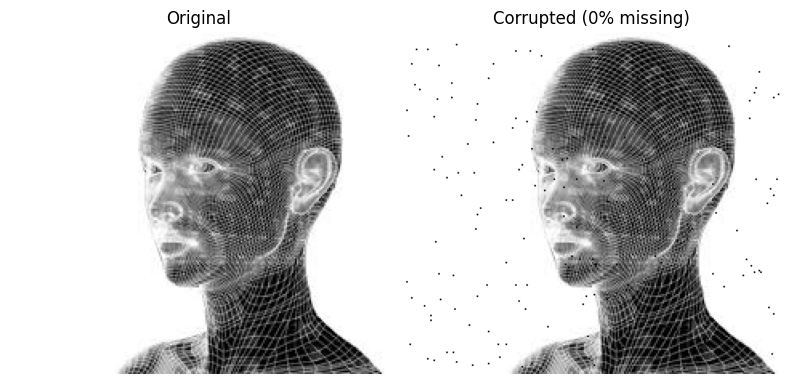

In [137]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrupted, cmap="gray")
plt.title(f"Corrupted ({int(missing_rate * 100)}% missing)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [138]:
recovered_manual = corrupted.copy()

for step in range(iterations):
    XtX = recovered_manual.T @ recovered_manual

    eigenvalues, V = np.linalg.eigh(XtX)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    V = V[:, idx]

    eigenvalues = np.clip(eigenvalues, 0, None)
    singular_values = np.sqrt(eigenvalues)

    singular_values = singular_values[:k]
    V = V[:, :k]

    U_columns = []
    valid_singular_values = []

    for i in range(len(singular_values)):
        sigma = singular_values[i]

        if sigma > 1e-10:
            u_i = recovered_manual @ V[:, i] / sigma
            U_columns.append(u_i)
            valid_singular_values.append(sigma)

    U = np.column_stack(U_columns)
    s = np.array(valid_singular_values)
    V = V[:, :len(valid_singular_values)]
    Vt = V.T

    X_approx_manual = U @ np.diag(s) @ Vt

    recovered_manual[~mask] = X_approx_manual[~mask]

    recovered_manual[mask] = corrupted[mask]

recovered_manual = np.clip(recovered_manual, 0, 1)

In [139]:
recovered_builtin = corrupted.copy()

for step in range(iterations):
    U_builtin, s_builtin, Vt_builtin = np.linalg.svd(recovered_builtin, full_matrices=False)

    U_builtin = U_builtin[:, :k]
    s_builtin = s_builtin[:k]
    Vt_builtin = Vt_builtin[:k, :]

    X_approx_builtin = U_builtin @ np.diag(s_builtin) @ Vt_builtin

    recovered_builtin[~mask] = X_approx_builtin[~mask]
    recovered_builtin[mask] = corrupted[mask]

recovered_builtin = np.clip(recovered_builtin, 0, 1)

In [140]:
difference = np.linalg.norm(recovered_manual - recovered_builtin)
print(f"Difference between manual and built-in recovery: {difference:.6f}")

Difference between manual and built-in recovery: 0.000000


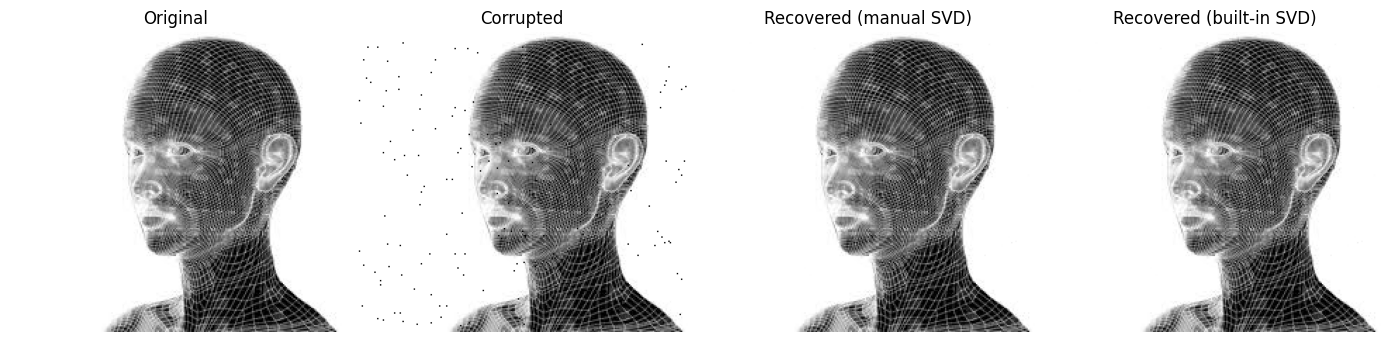

In [141]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(corrupted, cmap="gray")
plt.title("Corrupted")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(recovered_manual, cmap="gray")
plt.title("Recovered (manual SVD)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(recovered_builtin, cmap="gray")
plt.title("Recovered (built-in SVD)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [143]:
row1 = np.hstack((original, corrupted, recovered_manual, recovered_builtin))

cv2.imshow('SVD Recovery: Original | Corrupted | Recovered manual | Recovered build-in', row1)
cv2.waitKey(0)
cv2.destroyAllWindows()

Готово! Натисніть будь-яку клавішу.
